<a href="https://colab.research.google.com/github/Minsoo1036/Applied-Data-Analysis-Study/blob/main/IRF_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance statsmodels

/tmp/ipykernel_13684/646829373.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_13684/646829373.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.resample("M").mean()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     05:31:34
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -19.9354
Nobs:                     193.000    HQIC:                  -20.0561
Log likelihood:           1133.77    FPE:                1.79509e-09
AIC:                     -20.1382    Det(Omega_mle):     1.68795e-09
--------------------------------------------------------------------
Results for equation RATE
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const          -0.000078         0.001332           -0.059           0.953
L1.RATE         0.394699         0.075784            5.208           0.000
L1.SPX          0.095394         0.043946            2.171           0.030
L1.KRW    

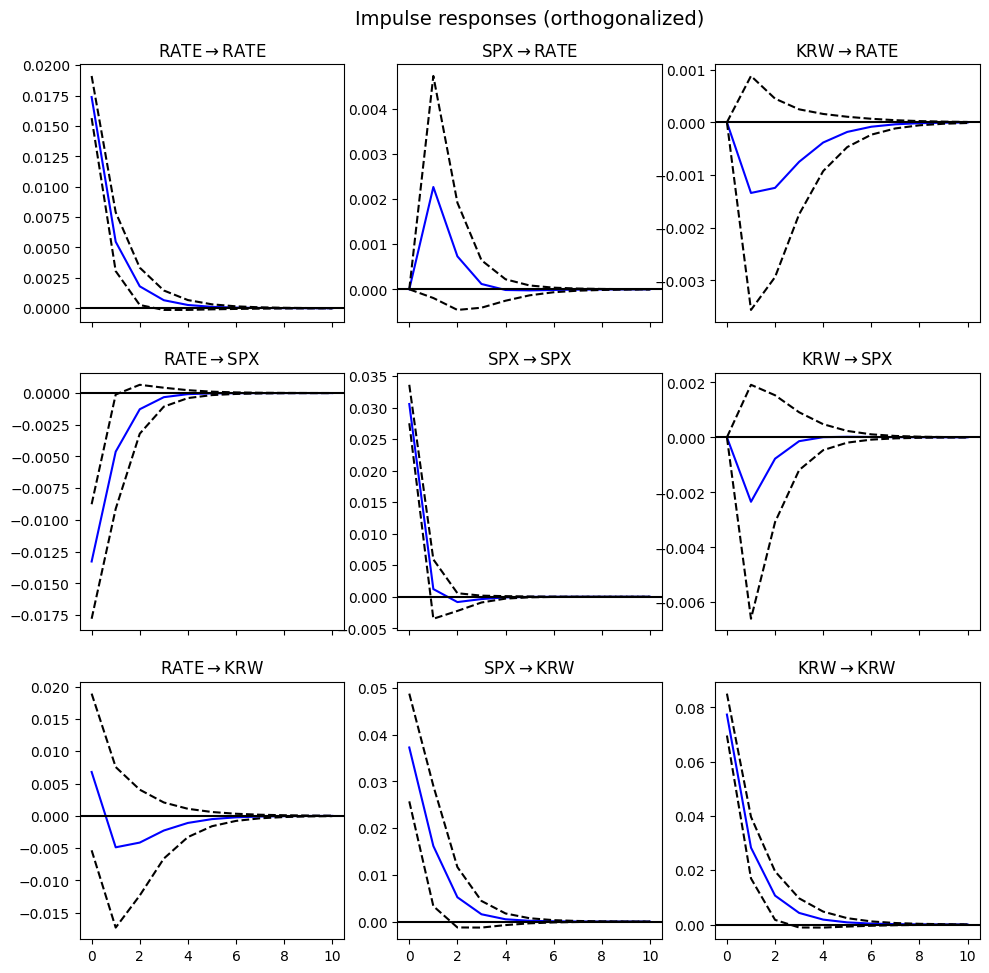

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# =========================================
# 1. 데이터 다운로드
# =========================================
tickers = ["^TNX", "^GSPC", "KRW=X"]

data = yf.download(tickers, start="2010-01-01")["Close"]

data.columns = ["RATE", "SPX", "KRW"]

data = data.resample("M").mean()
data.index = data.index.to_period("M").to_timestamp()
data = data.head(195)

# 로그수익률 (stationary)
df = np.log(data).diff().dropna()

# =========================================
# 2. VAR 모델 적합
# =========================================
model = VAR(df)

lag_order = model.select_order(maxlags=10)
p = lag_order.aic  # AIC 기준

var_model = model.fit(p)

print(var_model.summary())

# =========================================
# 3. IRF 계산
# =========================================
irf = var_model.irf(10)  # 10 step

# =========================================
# 4. IRF plot
# =========================================
irf.plot(orth=True)
plt.show()

In [3]:
df = df[["RATE", "SPX", "KRW"]]

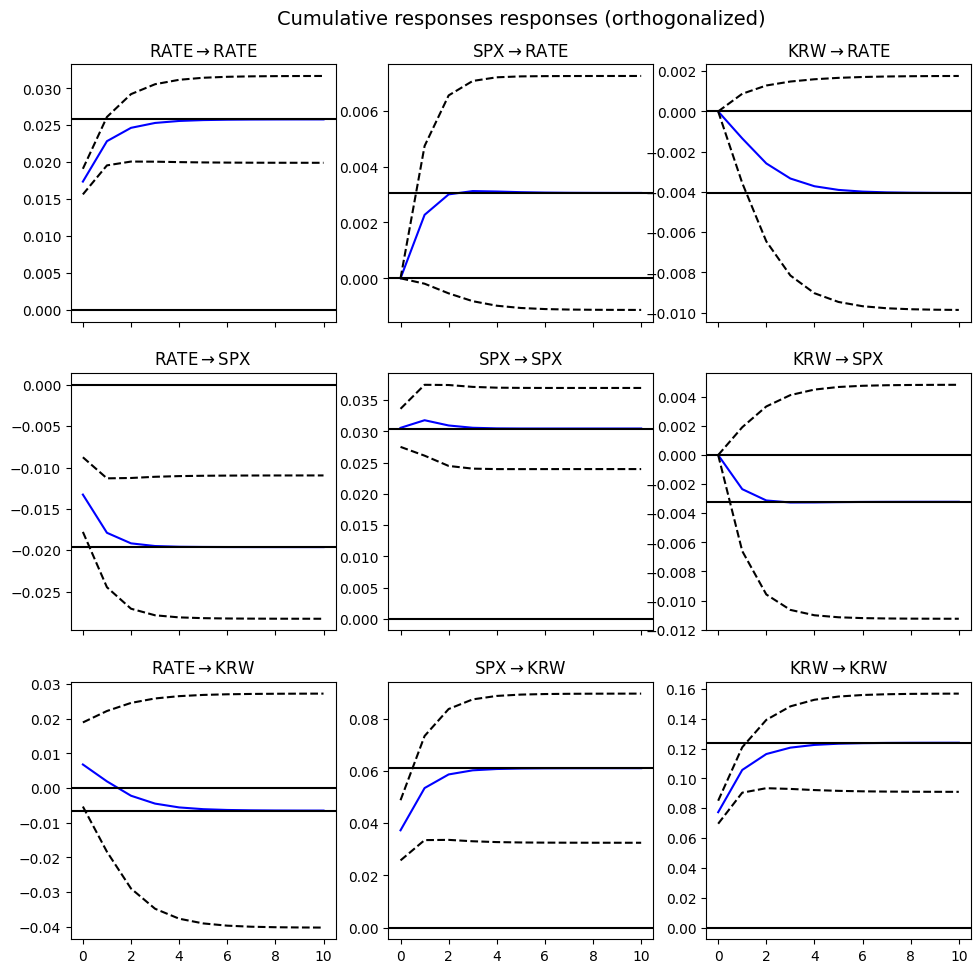

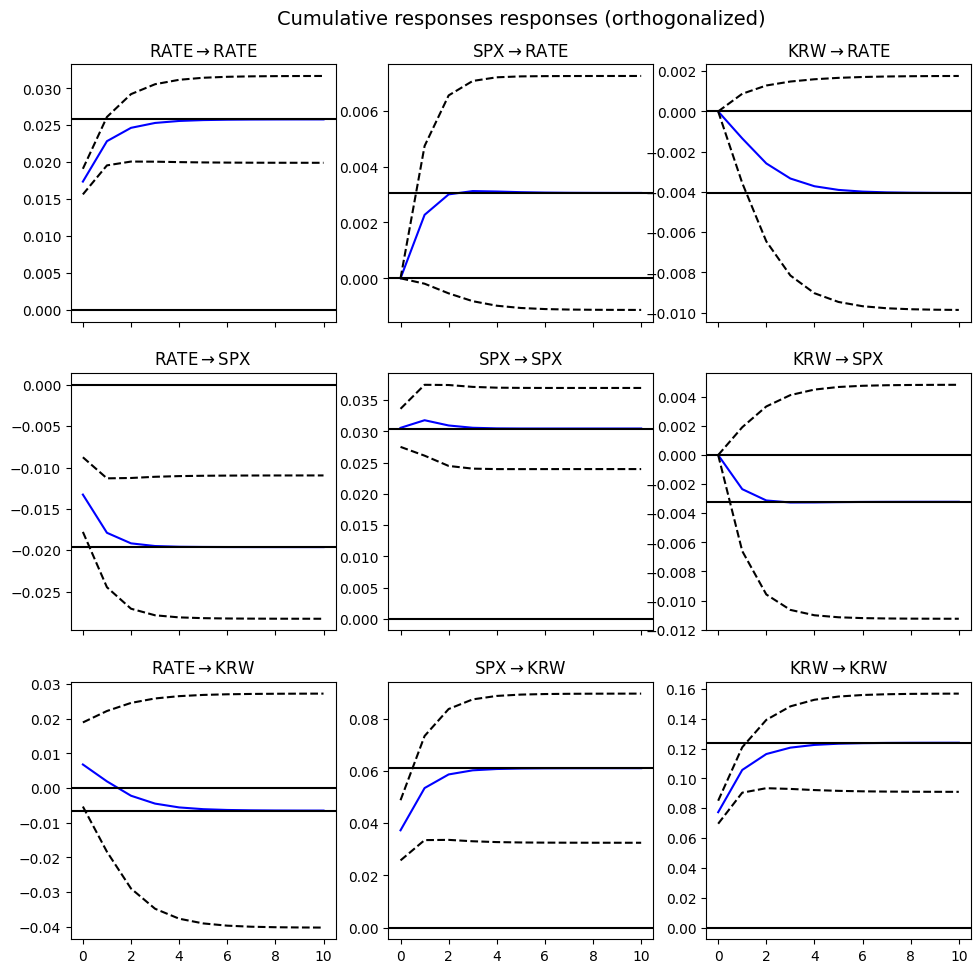

In [4]:
irf.plot_cum_effects(orth=True)

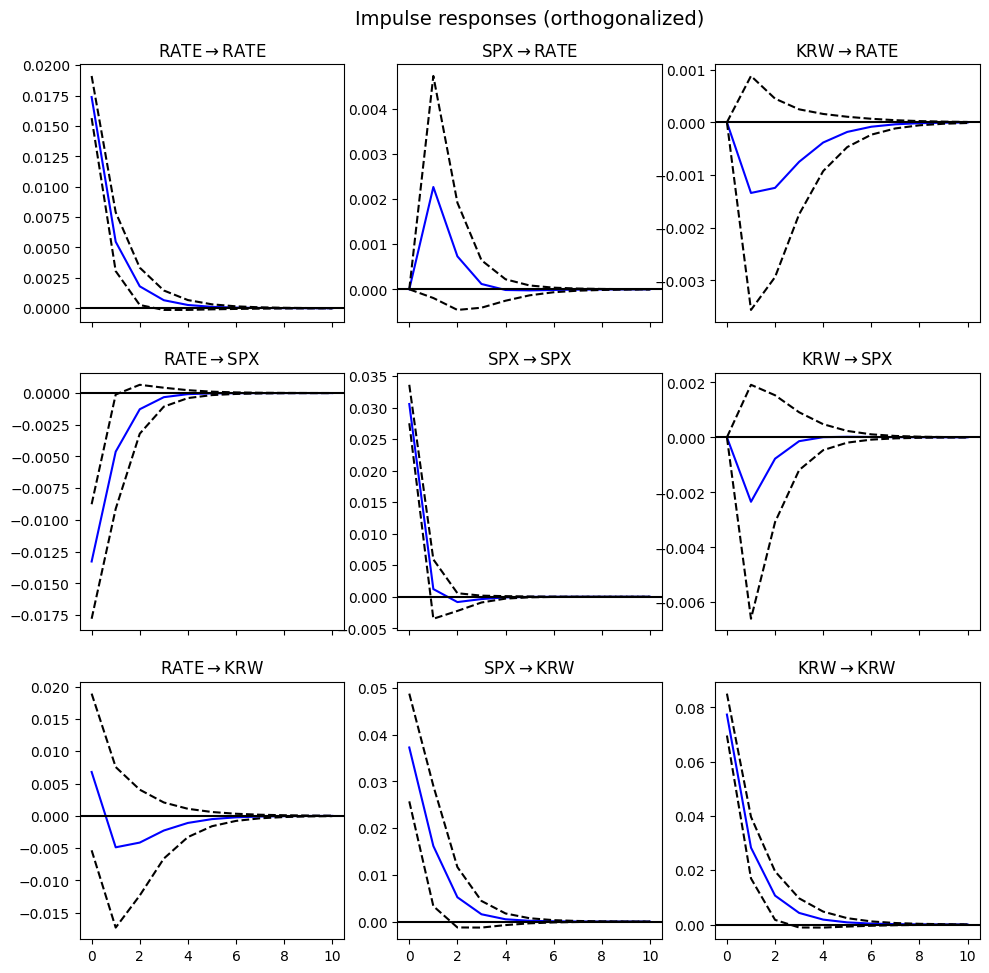

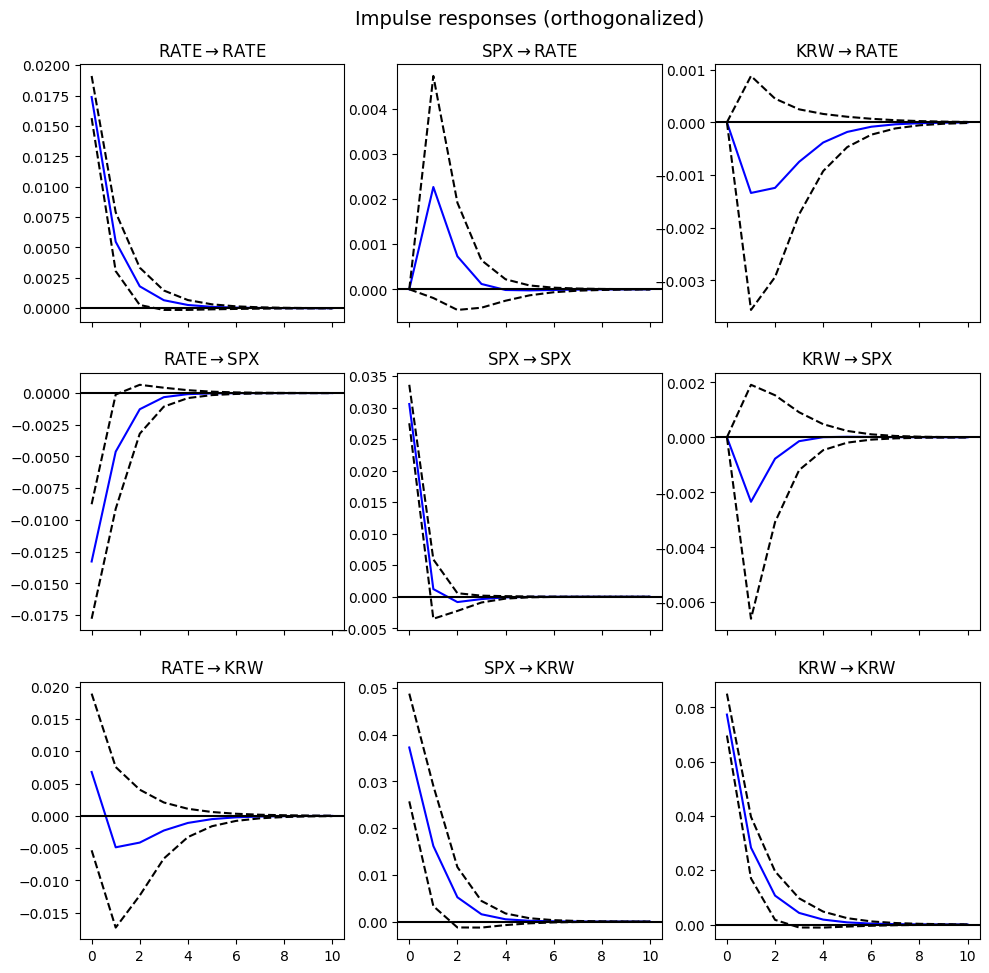

In [5]:
irf.plot(orth=True, signif=0.05)

In [6]:
data

,RATE,SPX,KRW
Date,,,
2010-01-01,1136.161906,1123.581582,3.711053
2010-02-01,1154.775000,1089.159989,3.679263
2010-03-01,1135.278262,1152.048690,3.719261
2010-04-01,1113.359086,1197.316185,3.819333
2010-05-01,1162.947626,1125.062006,3.412750
...,...,...,...
2025-11-01,1456.695001,6740.885768,4.089789
2025-12-01,1465.404097,6853.025457,4.141409
2026-01-01,1453.384766,6929.121973,4.205150


In [7]:
# IRF (returns 기준)
irf = var_model.irf(20)

# cumulative IRF
irf_cum = irf.cum_effects

In [8]:
# index 순서 확인
print(df.columns)

# 예: RATE shock → SPX 반응
response = irf_cum[:, df.columns.get_loc("KRW"), df.columns.get_loc("RATE")]

Index(['RATE', 'SPX', 'KRW'], dtype='object')


In [9]:
def get_level_irf(irf, df_cols, shock, response):
    irf_cum = irf.cum_effects

    i = df_cols.get_loc(response)
    j = df_cols.get_loc(shock)

    log_irf = irf_cum[:, i, j]
    level_irf = np.exp(log_irf)

    return level_irf

In [10]:
level_irf = get_level_irf(irf, df.columns, "RATE", "KRW")

In [11]:
horizon = len(level_irf)

price_path = np.insert(level_irf, 0, 1.0)  # 시작점 = 1

steps = np.arange(0, horizon+1)

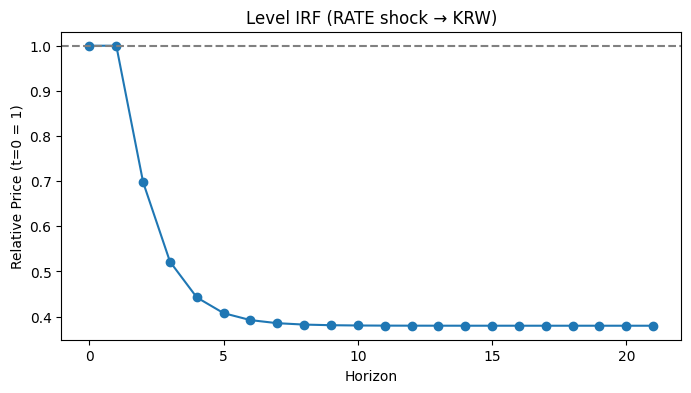

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(steps, price_path, marker='o')
plt.axhline(1.0, linestyle='--', color='gray')

plt.title("Level IRF (RATE shock → KRW)")
plt.ylabel("Relative Price (t=0 = 1)")
plt.xlabel("Horizon")

plt.show()

In [13]:
data.to_csv("irf_example_df.csv")